In [111]:
import sys
from pathlib import Path

# add project root to Python path
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [112]:
import numpy as np
from pathlib import Path

from src.processes import Mess3Component, sample_sequence, sample_balanced_mixture_dataset, split_by_sequence
from src.beliefs import compute_beliefs_for_sequence, compute_beliefs_for_dataset

rng = np.random.default_rng(0)
Path("../outputs/data").mkdir(parents=True, exist_ok=True)
Path("../outputs/plots").mkdir(parents=True, exist_ok=True)
Path("../outputs/checkpoints").mkdir(parents=True, exist_ok=True)

In [ ]:
import numpy as np
from src.processes import Mess3Component

token_labels = {0: "A", 1: "B", 2: "C"}
state_labels = {0: "S1", 1: "S2", 2: "S3"}

def tokens_to_symbols(tokens):
    return [token_labels[int(t)] for t in tokens]

def states_to_symbols(states):
    return [state_labels[int(s)] for s in states]

def format_emission_matrix(E):
    rows = []
    for i in range(E.shape[0]):
        probs = ", ".join(f"{token_labels[j]}={E[i, j]:.2f}" for j in range(E.shape[1]))
        rows.append(f"  {state_labels[i]}: {probs}")
    return "\n".join(rows)

def make_mess3_component(name: str, component_id: int, x: float, alpha: float):
    assert 0.0 <= x <= 0.5
    assert 0.0 <= alpha <= 1.0

    K = 3
    V = 3

    pi = np.array([1/3, 1/3, 1/3], dtype=np.float64)

    A = np.full((K, K), x, dtype=np.float64)
    np.fill_diagonal(A, 1 - 2 * x)

    E = np.full((K, V), (1 - alpha) / 2, dtype=np.float64)
    for i in range(K):
        E[i, i] = alpha

    comp = Mess3Component(
        name=name,
        component_id=component_id,
        pi=pi,
        A=A,
        E=E,
        vocab_size=V,
    )
    comp.validate()
    return comp

components = []

def make_component(component_id: int, x: float, alpha: float):
    name = f"mess3_c{component_id}_x{int(x*100):03d}_a{int(alpha*100):03d}"
    comp = make_mess3_component(name, component_id, x, alpha)
    components.append(comp)
    return comp

components = [
    make_component(0, x=0.05, alpha=0.90),
    make_component(1, x=0.18, alpha=0.95),
    make_component(2, x=0.05, alpha=0.45),
]

components_by_id = {c.component_id: c for c in components}

for c in components:
    print(c.name)
    print("pi =", c.pi)
    print("A =\n", c.A)
    print("E (tokens A/B/C) =")
    print(format_emission_matrix(c.E))
    print("A row sums:", c.A.sum(axis=1))
    print("E row sums:", c.E.sum(axis=1))
    print()


mess3_c0_x005_a090
pi = [0.33333333 0.33333333 0.33333333]
A =
 [[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]
E (tokens A/B/C) =
  S1: A=0.90, B=0.05, C=0.05
  S2: A=0.05, B=0.90, C=0.05
  S3: A=0.05, B=0.05, C=0.90
A row sums: [1. 1. 1.]
E row sums: [1. 1. 1.]

mess3_c1_x018_a090
pi = [0.33333333 0.33333333 0.33333333]
A =
 [[0.64 0.18 0.18]
 [0.18 0.64 0.18]
 [0.18 0.18 0.64]]
E (tokens A/B/C) =
  S1: A=0.90, B=0.05, C=0.05
  S2: A=0.05, B=0.90, C=0.05
  S3: A=0.05, B=0.05, C=0.90
A row sums: [1. 1. 1.]
E row sums: [1. 1. 1.]

mess3_c2_x005_a055
pi = [0.33333333 0.33333333 0.33333333]
A =
 [[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]
E (tokens A/B/C) =
  S1: A=0.55, B=0.22, C=0.22
  S2: A=0.22, B=0.55, C=0.22
  S3: A=0.22, B=0.22, C=0.55
A row sums: [1. 1. 1.]
E row sums: [1. 1. 1.]



In [114]:
from src.processes import sample_sequence

rng = np.random.default_rng(0)

for comp in components:
    print("==", comp.name, "==")
    for _ in range(3):
        tokens, states = sample_sequence(comp, seq_len=16, rng=rng)
        print("states:", states_to_symbols(states))
        print("tokens:", tokens_to_symbols(tokens))
    print()


== mess3_c0_x005_a090 ==
states: ['S2', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S3', 'S3', 'S3']
tokens: ['B', 'A', 'B', 'A', 'B', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'A', 'C', 'C', 'C']
states: ['S1', 'S1', 'S1', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2']
tokens: ['A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'B']
states: ['S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S1', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S2', 'S1', 'S3']
tokens: ['A', 'B', 'A', 'B', 'C', 'A', 'C', 'B', 'B', 'B', 'B', 'B', 'B', 'C', 'A', 'C']

== mess3_c1_x018_a090 ==
states: ['S1', 'S3', 'S3', 'S3', 'S2', 'S2', 'S1', 'S1', 'S2', 'S2', 'S3', 'S3', 'S2', 'S3', 'S2', 'S3']
tokens: ['C', 'C', 'C', 'C', 'B', 'B', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'C', 'B', 'C']
states: ['S1', 'S1', 'S2', 'S2', 'S2', 'S3', 'S3', 'S3', 'S3', 'S1', 'S1', 'S1', 'S1', 'S1', 'S3', 'S3']
tokens: ['A', 'A', 'B', 'B', 'B', 'C', 'C', 'C', 'C', 'A', 'A', 'A',

In [115]:
def quick_stats(tokens_batch, states_batch):
    same_state = (states_batch[:, 1:] == states_batch[:, :-1]).mean()
    token_match = (tokens_batch == states_batch).mean()
    return same_state, token_match

for comp in components:
    toks = []
    sts = []
    for _ in range(2000):
        t, s = sample_sequence(comp, seq_len=32, rng=rng)
        toks.append(t)
        sts.append(s)
    toks = np.stack(toks)
    sts = np.stack(sts)

    same_state, token_match = quick_stats(toks, sts)
    print(comp.name)
    print("empirical P(same next state):", round(float(same_state), 3))
    print("empirical P(token matches preferred token of state): ", round(float(token_match), 3))
    print()

mess3_c0_x005_a090
empirical P(same next state): 0.899
empirical P(token matches preferred token of state):  0.901

mess3_c1_x018_a090
empirical P(same next state): 0.641
empirical P(token matches preferred token of state):  0.9

mess3_c2_x005_a055
empirical P(same next state): 0.899
empirical P(token matches preferred token of state):  0.546



In [116]:
from src.processes import sample_sequence
from src.beliefs import compute_beliefs_for_sequence

comp = components[0]
tokens, states = sample_sequence(comp, seq_len=10, rng=rng)
beliefs = compute_beliefs_for_sequence(tokens, comp.pi, comp.A, comp.E)

print("states:", states_to_symbols(states))
print("tokens:", tokens_to_symbols(tokens))
print()

print("filtered beliefs P(z_t | x_<=t):")
print(np.round(beliefs["filtered_after_obs"], 3))
print()

print("predictive next beliefs P(z_{t+1} | x_<=t):")
print(np.round(beliefs["predictive_next"], 3))
print()

print("row sums filtered:", beliefs["filtered_after_obs"].sum(axis=1))
print("row sums predictive_next:", beliefs["predictive_next"].sum(axis=1))
print("loglik:", beliefs["loglik"])


states: ['S3', 'S2', 'S2', 'S3', 'S3', 'S3', 'S3', 'S1', 'S1', 'S1']
tokens: ['C', 'B', 'B', 'A', 'C', 'C', 'B', 'A', 'A', 'A']

filtered beliefs P(z_t | x_<=t):
[[0.05  0.05  0.9  ]
 [0.036 0.647 0.317]
 [0.007 0.964 0.029]
 [0.517 0.445 0.038]
 [0.204 0.179 0.617]
 [0.021 0.019 0.961]
 [0.032 0.56  0.409]
 [0.601 0.227 0.172]
 [0.958 0.023 0.019]
 [0.991 0.004 0.004]]

predictive next beliefs P(z_{t+1} | x_<=t):
[[0.092 0.092 0.815]
 [0.081 0.6   0.319]
 [0.056 0.87  0.074]
 [0.489 0.428 0.082]
 [0.223 0.202 0.575]
 [0.068 0.066 0.866]
 [0.077 0.526 0.397]
 [0.561 0.243 0.196]
 [0.865 0.07  0.066]
 [0.893 0.054 0.054]]

row sums filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
row sums predictive_next: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
loglik: -14.080449485969755


In [117]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

from src.beliefs import compute_beliefs_for_sequence


def enumerate_prefix_beliefs(component, max_len=8, use="filtered_after_obs"):
    """
    Enumerate all token prefixes of lengths 1..max_len and compute beliefs.
    
    Returns:
        prefixes: list of tuples
        beliefs: np.ndarray [num_prefixes, 3]
        lengths: np.ndarray [num_prefixes]
    """
    prefixes = []
    beliefs = []
    lengths = []

    vocab = list(range(component.vocab_size))

    for L in range(1, max_len + 1):
        for prefix in itertools.product(vocab, repeat=L):
            prefix = np.array(prefix, dtype=np.int64)
            out = compute_beliefs_for_sequence(prefix, component.pi, component.A, component.E)
            b = out[use][-1]   # belief after full prefix
            prefixes.append(tuple(prefix.tolist()))
            beliefs.append(b)
            lengths.append(L)

    return prefixes, np.array(beliefs), np.array(lengths)


def simplex_to_2d(beliefs):
    """
    Map 3-state belief vectors [P(S1), P(S2), P(S3)] to 2D coordinates in an equilateral triangle.
    Vertices:
      S1 -> (0,0)
      S2 -> (1,0)
      S3 -> (0.5, sqrt(3)/2)
    """
    v0 = np.array([0.0, 0.0])
    v1 = np.array([1.0, 0.0])
    v2 = np.array([0.5, np.sqrt(3) / 2.0])

    xy = (
        beliefs[:, [0]] * v0
        + beliefs[:, [1]] * v1
        + beliefs[:, [2]] * v2
    )
    return xy


def draw_simplex(ax):
    tri = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, np.sqrt(3) / 2.0],
        [0.0, 0.0],
    ])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=1.5)
    ax.text(-0.03, -0.04, "S1", fontsize=10)
    ax.text(1.01, -0.04, "S2", fontsize=10, ha="left")
    ax.text(0.5, np.sqrt(3)/2 + 0.03, "S3", fontsize=10, ha="center")
    ax.set_aspect("equal")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, np.sqrt(3)/2 + 0.08)
    ax.axis("off")

C:\Users\nikak\AppData\Local\Temp\ipykernel_19224\1916839862.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


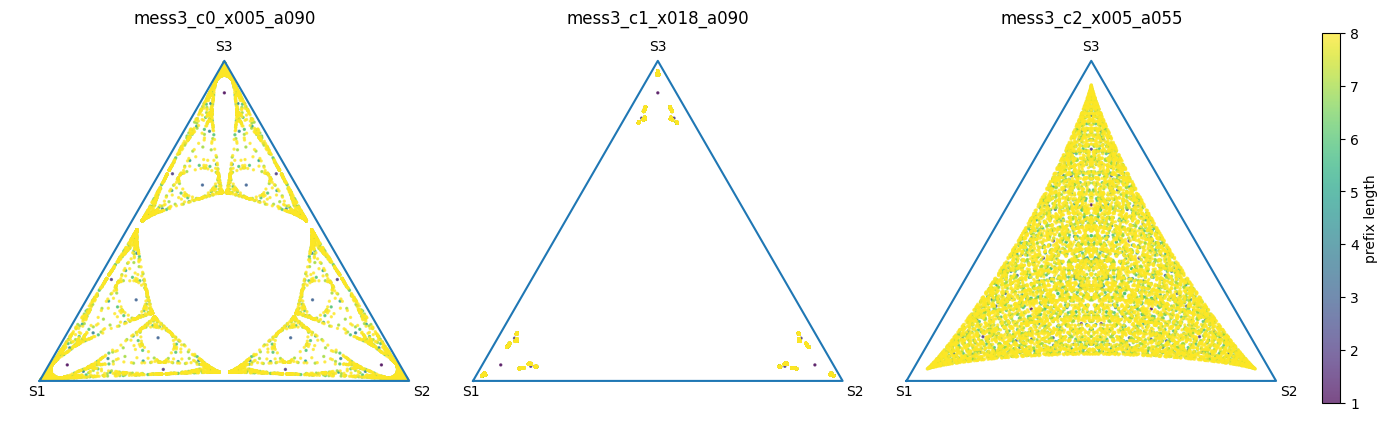

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, comp in zip(axes, components):
    prefixes, beliefs, lengths = enumerate_prefix_beliefs(
        comp,
        max_len=8,
        use="filtered_after_obs",
    )
    xy = simplex_to_2d(beliefs)

    draw_simplex(ax)

    sc = ax.scatter(
        xy[:,0],
        xy[:,1],
        c=lengths,
        cmap="viridis",
        s=2,
        alpha=0.7,
    )

    ax.set_title(comp.name)

cbar = fig.colorbar(
    sc,
    ax=axes,
    location="right",
    fraction=0.02,
    pad=-0.17
)

cbar.set_label("prefix length")

plt.tight_layout()
plt.show()

In [119]:
def print_mess3_hmm_text(component):
    """Print each directed transition and its token probabilities."""
    state_labels = {0: "S1", 1: "S2", 2: "S3"}
    token_labels = {0: "A", 1: "B", 2: "C"}
    print(component.name)
    print("-" * len(component.name))
    print("State emissions (conditional on being in that hidden state):")
    for i in range(component.E.shape[0]):
        emission_text = ", ".join(
            f"{token_labels[token]}: {100 * prob:.1f}%"
            for token, prob in enumerate(component.E[i])
        )
        print(f"  {state_labels[i]} emits -> {emission_text}")
    print()
    print("Directed transitions with token breakdown:")
    for i in range(component.A.shape[0]):
        for j in range(component.A.shape[1]):
            transition_prob = float(component.A[i, j])
            token_probs = transition_prob * component.E[j]
            token_text = ", ".join(
                f"{token_labels[token]}: {100 * prob:.1f}%"
                for token, prob in enumerate(token_probs)
            )
            print(
                f"  {state_labels[i]} -> {state_labels[j]} | Total: {100 * transition_prob:.1f}% | {token_text}"
            )
    print()

for comp in components:
    print_mess3_hmm_text(comp)


mess3_c0_x005_a090
------------------
State emissions (conditional on being in that hidden state):
  S1 emits -> A: 90.0%, B: 5.0%, C: 5.0%
  S2 emits -> A: 5.0%, B: 90.0%, C: 5.0%
  S3 emits -> A: 5.0%, B: 5.0%, C: 90.0%

Directed transitions with token breakdown:
  S1 -> S1 | Total: 90.0% | A: 81.0%, B: 4.5%, C: 4.5%
  S1 -> S2 | Total: 5.0% | A: 0.2%, B: 4.5%, C: 0.2%
  S1 -> S3 | Total: 5.0% | A: 0.2%, B: 0.2%, C: 4.5%
  S2 -> S1 | Total: 5.0% | A: 4.5%, B: 0.2%, C: 0.2%
  S2 -> S2 | Total: 90.0% | A: 4.5%, B: 81.0%, C: 4.5%
  S2 -> S3 | Total: 5.0% | A: 0.2%, B: 0.2%, C: 4.5%
  S3 -> S1 | Total: 5.0% | A: 4.5%, B: 0.2%, C: 0.2%
  S3 -> S2 | Total: 5.0% | A: 0.2%, B: 4.5%, C: 0.2%
  S3 -> S3 | Total: 90.0% | A: 4.5%, B: 4.5%, C: 81.0%

mess3_c1_x018_a090
------------------
State emissions (conditional on being in that hidden state):
  S1 emits -> A: 90.0%, B: 5.0%, C: 5.0%
  S2 emits -> A: 5.0%, B: 90.0%, C: 5.0%
  S3 emits -> A: 5.0%, B: 5.0%, C: 90.0%

Directed transitions with t

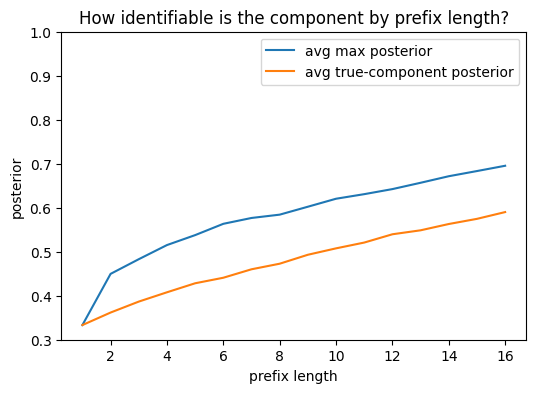

final avg max posterior at t=16: 0.6953513527821976
final avg true-component posterior at t=16: 0.5901036729501582


In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

from src.processes import sample_sequence
from src.beliefs import compute_beliefs_for_sequence

def sequence_loglik_under_component(tokens, comp):
    out = compute_beliefs_for_sequence(tokens, comp.pi, comp.A, comp.E)
    return out["loglik"]

def component_posterior_over_prefixes(tokens, components):
    """
    Returns posterior over components after each prefix.
    Assumes uniform prior over components.
    """
    T = len(tokens)
    C = len(components)
    log_posts = np.zeros((T, C), dtype=np.float64)

    for t in range(1, T + 1):
        prefix = tokens[:t]
        ll = np.array([sequence_loglik_under_component(prefix, c) for c in components])
        ll = ll - logsumexp(ll)
        log_posts[t - 1] = ll

    return np.exp(log_posts)

def diagnostic_component_identifiability(components, seq_len=16, n_samples_per_component=200, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    all_posteriors = []
    true_ids = []

    for true_comp in components:
        for _ in range(n_samples_per_component):
            tokens, _ = sample_sequence(true_comp, seq_len=seq_len, rng=rng)
            post = component_posterior_over_prefixes(tokens, components)   # [T, C]
            all_posteriors.append(post)
            true_ids.append(true_comp.component_id)

    all_posteriors = np.stack(all_posteriors)  # [N, T, C]
    true_ids = np.array(true_ids)

    max_post = all_posteriors.max(axis=2)  # [N, T]

    true_comp_post = np.zeros((len(true_ids), seq_len))
    for i in range(len(true_ids)):
        true_comp_post[i] = all_posteriors[i, :, true_ids[i]]

    return {
        "all_posteriors": all_posteriors,
        "true_ids": true_ids,
        "avg_max_post_by_t": max_post.mean(axis=0),
        "avg_true_post_by_t": true_comp_post.mean(axis=0),
    }

diag = diagnostic_component_identifiability(
    components,
    seq_len=16,
    n_samples_per_component=300,
    rng=np.random.default_rng(0),
)

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, 17), diag["avg_max_post_by_t"], label="avg max posterior")
plt.plot(np.arange(1, 17), diag["avg_true_post_by_t"], label="avg true-component posterior")
plt.xlabel("prefix length")
plt.ylabel("posterior")
plt.ylim(0.3, 1.0)
plt.legend()
plt.title("How identifiable is the component by prefix length?")
plt.show()

print("final avg max posterior at t=16:", diag["avg_max_post_by_t"][-1])
print("final avg true-component posterior at t=16:", diag["avg_true_post_by_t"][-1])

In [ ]:
def search_component_triples(
    fixed_c0=(0.05, 0.90),
    c1_x_grid=(0.16, 0.18, 0.20, 0.22, 0.24),
    c1_alpha_grid=(0.85, 0.90, 0.95),
    c2_x_grid=(0.03, 0.05, 0.07, 0.09),
    c2_alpha_grid=(0.45, 0.50, 0.55, 0.60, 0.65),
    seq_len=16,
    n_samples_per_component=150,
    rng_seed=0,
    top_k=10,
):
    results = []

    for c1_x in c1_x_grid:
        for c1_alpha in c1_alpha_grid:
            for c2_x in c2_x_grid:
                for c2_alpha in c2_alpha_grid:
                    candidate_components = [
                        make_mess3_component(
                            f"mess3_c0_x{int(fixed_c0[0] * 100):03d}_a{int(fixed_c0[1] * 100):03d}",
                            0,
                            x=fixed_c0[0],
                            alpha=fixed_c0[1],
                        ),
                        make_mess3_component(
                            f"mess3_c1_x{int(c1_x * 100):03d}_a{int(c1_alpha * 100):03d}",
                            1,
                            x=c1_x,
                            alpha=c1_alpha,
                        ),
                        make_mess3_component(
                            f"mess3_c2_x{int(c2_x * 100):03d}_a{int(c2_alpha * 100):03d}",
                            2,
                            x=c2_x,
                            alpha=c2_alpha,
                        ),
                    ]

                    diag = diagnostic_component_identifiability(
                        candidate_components,
                        seq_len=seq_len,
                        n_samples_per_component=n_samples_per_component,
                        rng=np.random.default_rng(rng_seed),
                    )

                    results.append({
                        "c1_x": c1_x,
                        "c1_alpha": c1_alpha,
                        "c2_x": c2_x,
                        "c2_alpha": c2_alpha,
                        "final_avg_max": float(diag["avg_max_post_by_t"][-1]),
                        "final_avg_true": float(diag["avg_true_post_by_t"][-1]),
                    })

    results.sort(
        key=lambda row: (row["final_avg_true"], row["final_avg_max"]),
        reverse=True,
    )

    print(f"Top {top_k} candidates with c0 fixed at x={fixed_c0[0]:.2f}, alpha={fixed_c0[1]:.2f}:")
    for row in results[:top_k]:
        print(
            f"c1=(x={row['c1_x']:.2f}, a={row['c1_alpha']:.2f}), "
            f"c2=(x={row['c2_x']:.2f}, a={row['c2_alpha']:.2f}) "
            f"-> avg_max={row['final_avg_max']:.3f}, avg_true={row['final_avg_true']:.3f}"
        )

    return results

# search_results = search_component_triples()

'''
Top 10 candidates with c0 fixed at x=0.05, alpha=0.90:
c1=(x=0.18, a=0.95), c2=(x=0.03, a=0.45) -> avg_max=0.751, avg_true=0.660
c1=(x=0.18, a=0.95), c2=(x=0.07, a=0.45) -> avg_max=0.752, avg_true=0.659
c1=(x=0.18, a=0.95), c2=(x=0.05, a=0.45) -> avg_max=0.750, avg_true=0.656
c1=(x=0.18, a=0.95), c2=(x=0.09, a=0.45) -> avg_max=0.751, avg_true=0.656
c1=(x=0.16, a=0.95), c2=(x=0.03, a=0.45) -> avg_max=0.748, avg_true=0.655
c1=(x=0.16, a=0.95), c2=(x=0.07, a=0.45) -> avg_max=0.749, avg_true=0.654
c1=(x=0.20, a=0.95), c2=(x=0.03, a=0.45) -> avg_max=0.747, avg_true=0.652
c1=(x=0.16, a=0.95), c2=(x=0.09, a=0.45) -> avg_max=0.748, avg_true=0.652
c1=(x=0.20, a=0.95), c2=(x=0.07, a=0.45) -> avg_max=0.750, avg_true=0.651
c1=(x=0.16, a=0.95), c2=(x=0.05, a=0.45) -> avg_max=0.747, avg_true=0.651
'''


Top 10 candidates with c0 fixed at x=0.05, alpha=0.90:
c1=(x=0.18, a=0.95), c2=(x=0.03, a=0.45) -> avg_max=0.751, avg_true=0.660
c1=(x=0.18, a=0.95), c2=(x=0.07, a=0.45) -> avg_max=0.752, avg_true=0.659
c1=(x=0.18, a=0.95), c2=(x=0.05, a=0.45) -> avg_max=0.750, avg_true=0.656
c1=(x=0.18, a=0.95), c2=(x=0.09, a=0.45) -> avg_max=0.751, avg_true=0.656
c1=(x=0.16, a=0.95), c2=(x=0.03, a=0.45) -> avg_max=0.748, avg_true=0.655
c1=(x=0.16, a=0.95), c2=(x=0.07, a=0.45) -> avg_max=0.749, avg_true=0.654
c1=(x=0.20, a=0.95), c2=(x=0.03, a=0.45) -> avg_max=0.747, avg_true=0.652
c1=(x=0.16, a=0.95), c2=(x=0.09, a=0.45) -> avg_max=0.748, avg_true=0.652
c1=(x=0.20, a=0.95), c2=(x=0.07, a=0.45) -> avg_max=0.750, avg_true=0.651
c1=(x=0.16, a=0.95), c2=(x=0.05, a=0.45) -> avg_max=0.747, avg_true=0.651
